In [1]:
import unicodedata, sys
from collections import Counter
import numpy as np
import pickle as pk
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model_family = 'umt5'
dictionary = pk.load(open("dictionaries/all_clusters_df.pk", "rb"))
vocab_file = f'vocab/{model_family}_vocab.npy'
vocab = np.load(vocab_file, allow_pickle=True)
vocab_categories_file = f'vocab/{model_family}_categories.npy'
vocab_categories = np.load(vocab_categories_file, allow_pickle=True)
map_file = f'vocab/m_x_u_{model_family}_map.npy'
vocab_map = np.load(map_file, allow_pickle=True)
vocab_translations_file = f'vocab/{model_family}_translations.npy'
vocab_translations = np.load(vocab_translations_file, allow_pickle=True)

subset_vocab = vocab[vocab_map]
subset_vocab_categories = vocab_categories[vocab_map]
subset_vocab_translations = vocab_translations[vocab_map]

In [3]:
model_name = 'umt5-base'
neighbor_file = f'{model_name}/m_x_u_neighbors.tsv'

In [76]:
model_name = "xlm-roberta-base"
df = pd.read_csv(f"{model_name}/m_x_u_neighbors_meaning.tsv", sep='\t', quoting=csv.QUOTE_NONE, header=None)
df.columns = ['cos', 'vocab_index','vocab', 'vocab_category', 'vocab_syn', 'neighbor_index', 'neighbor_vocab', 'neighbor_syn', 'has_overlap']

In [79]:
import pandas as pd
import scipy.stats

def get_entropy(data):
    """Calculates entropy of the passed `pd.Series`
    """
    p_data = data.value_counts()           # counts occurrence of each value
    entropy = scipy.stats.entropy(p_data)  # get entropy from counts
    return entropy

In [80]:
model_name = 'xlm-roberta-base'

df = pd.read_csv(f"{model_name}/m_x_u_neighbors_categories.tsv", sep='\t', quoting=csv.QUOTE_NONE, header=None)
df.columns = ['cos', 'vocab_index','vocab', 'vocab_category', 'neighbor_index', 'neighbor_vocab', 'neighbor_category']
stats = df.groupby(['vocab_index', 'vocab_category','neighbor_category']).size().reset_index(name='n')

stats.groupby(['vocab_index'])['n'].apply(get_entropy)

In [93]:
model_name = 'mt5-base'

df = pd.read_csv(f"{model_name}/m_x_u_neighbors_categories.tsv", sep='\t', quoting=csv.QUOTE_NONE, header=None)
df.columns = ['cos', 'vocab_index','vocab', 'vocab_category', 'neighbor_index', 'neighbor_vocab', 'neighbor_category']


In [88]:
model_name = 'mt5-base'

df = pd.read_csv(f"{model_name}/m_x_u_neighbors_categories.tsv", sep='\t', quoting=csv.QUOTE_NONE, header=None)
df.columns = ['cos', 'vocab_index','vocab', 'vocab_category', 'neighbor_index', 'neighbor_vocab', 'neighbor_category']
stats = df.groupby(['vocab_index', 'vocab_category','neighbor_category']).size().reset_index(name='n')

stats = stats.groupby(['vocab_index', 'vocab_category'])['n'].apply(get_entropy).reset_index(name="entropy")
stats = stats.groupby(['vocab_category'])['entropy'].agg(['mean', 'sem']).reset_index()
stats['ci'] = stats['sem'] * 1.96
stats = stats.drop("sem", axis=1)
stats = stats.fillna(0)
stats['model_name'] = model_name
for line in stats[['vocab_category', 'model_name', 'mean', 'ci']].values:
    f.write(f"{line[0]}\t{line[1]}\t{line[2]}\t{line[3]}\n")

,vocab_index,vocab_category,entropy
0,0,LATIN,1.214890
1,1,M,1.890557
2,2,LATIN,1.609438
3,3,LATIN,1.454867
4,4,CJK,1.698783


In [47]:
def plot_neighbor_meaning_by_category(model_name):
    df = pd.read_csv(f"{model_name}/m_x_u_neighbors_meaning.tsv", sep='\t', quoting=csv.QUOTE_NONE, header=None)
    df.columns = ['cos', 'vocab_index','vocab', 'vocab_syn', 'neighbor_index', 'neighbor_vocab', 'neighbor_syn', 'has_overlap']
    df['vocab_category'] = df['vocab_index'].apply(lambda idx: subset_vocab_categories[idx])
    stats = df.groupby(['vocab_index', 'vocab_category'])['has_overlap'].sum().reset_index(name='n')
    plt.figure(figsize=(8, 8))
    order = stats.groupby("vocab_category")['n'].mean().reset_index().sort_values("n", ascending=False)['vocab_category'].values
    stats = df.groupby(['vocab_index', 'vocab', 'vocab_category'])['has_overlap'].sum().reset_index(name="n")
    sns.barplot(data=stats, y='vocab_category', x='n', orient='h', order=order)
    plt.title(model_name)
    plt.savefig(f"./figures/{model_name}-neighbor-meaning-by-category.png", bbox_inches='tight')
    

xlm-roberta-large
xlm-roberta-xxl
xlm-roberta-xl
xlm-roberta-base


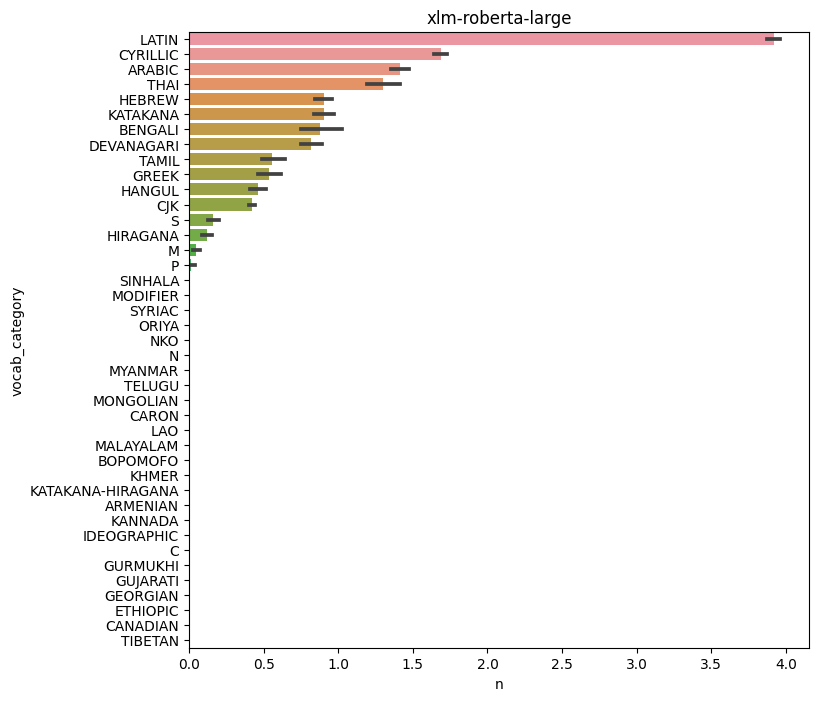

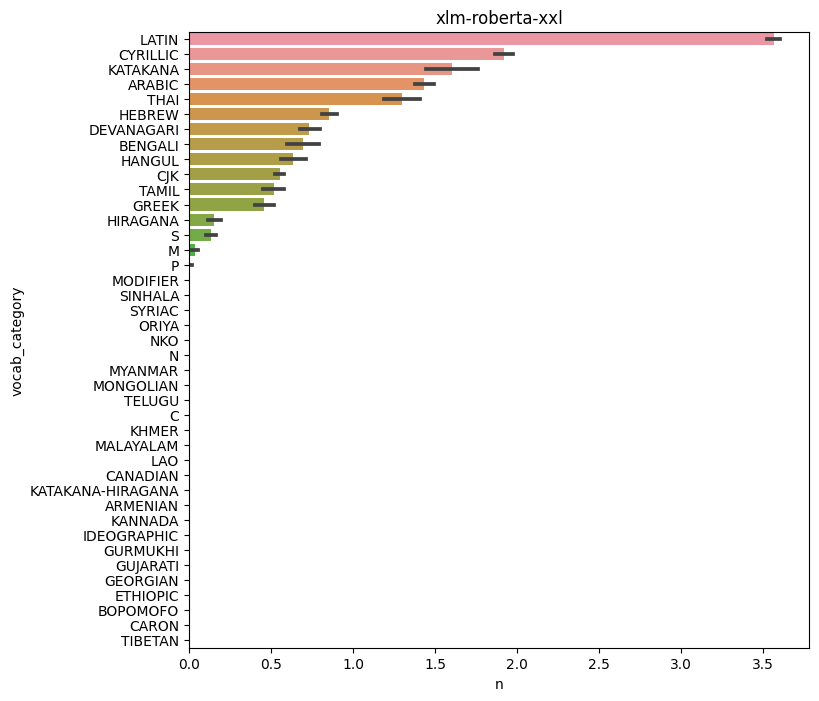

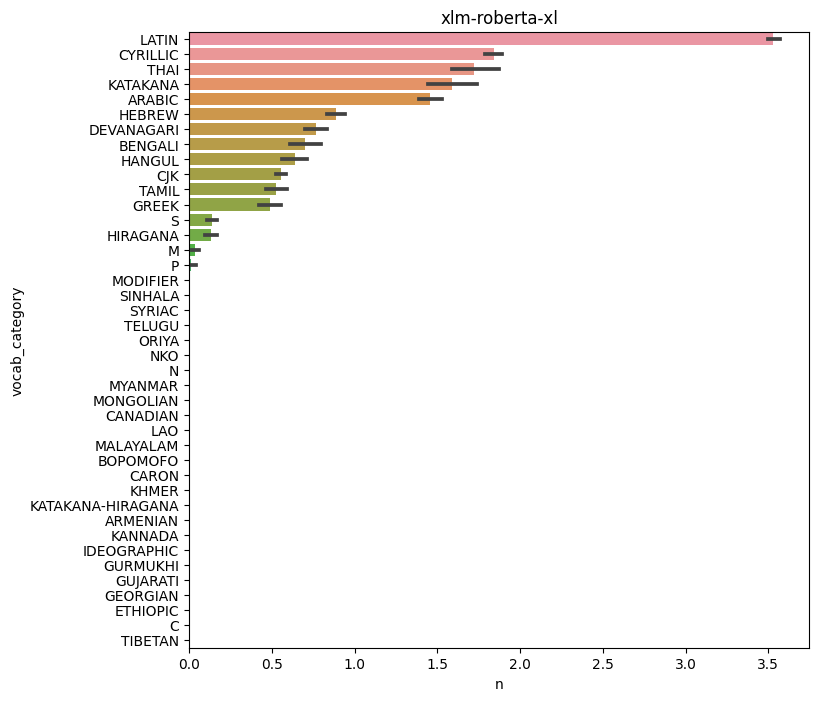

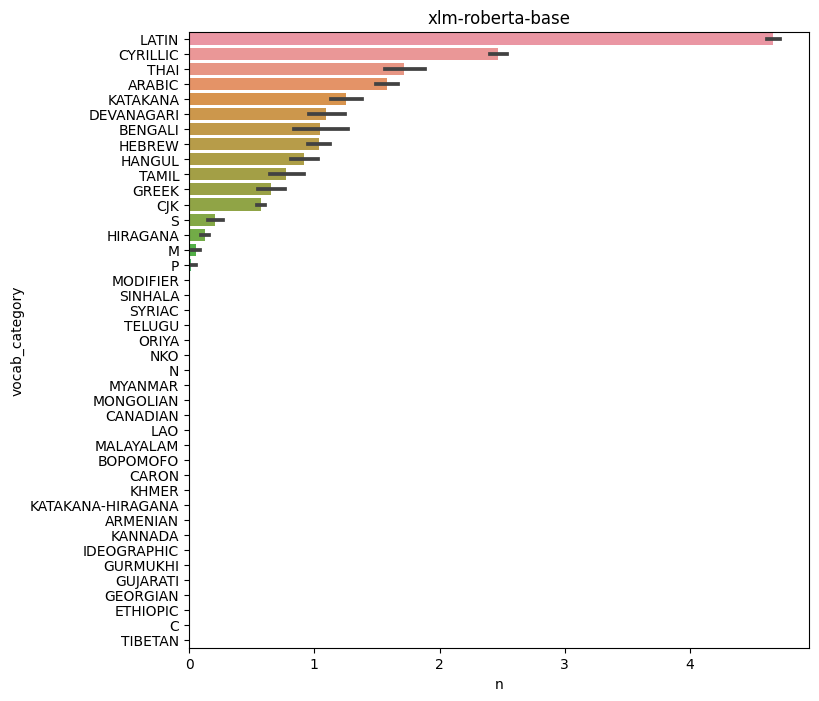

In [50]:
from pathlib import Path
model_dir = Path("./")
model_family = 'xlm'
model_names = [str(p) for p in model_dir.glob(f"{model_family}-*")]
for model_name in model_names:
    print(model_name)
    plot_neighbor_meaning_by_category(model_name)

In [2]:
def plot_category_heatmap(model_name):
    df = pd.read_csv(f"{model_name}/m_x_u_neighbors_categories.tsv", sep='\t', quoting=csv.QUOTE_NONE, header=None)
    df.columns = ['cos', 'vocab_index','vocab', 'vocab_category', 'neighbor_index', 'neighbor_vocab', 'neighbor_category']
    stats = df.groupby(['vocab_index', 'vocab_category','neighbor_category']).size().reset_index(name='n')
    stats['percent'] = stats['n'] / stats.groupby('vocab_index')['n'].transform('sum')
    stats = stats.groupby(['vocab_category', 'neighbor_category'])['percent'].mean().reset_index()
    table = pd.pivot_table(stats, values='percent', index='vocab_category',
                           columns='neighbor_category').fillna(0)
    
    plt.figure(figsize=(10,10))
    sns.heatmap(table, cmap="rocket_r", vmin=0, vmax=1)
    plt.title(model_name)
    plt.savefig(f"./figures/{model_name}-category-heatmap.png", bbox_inches='tight')

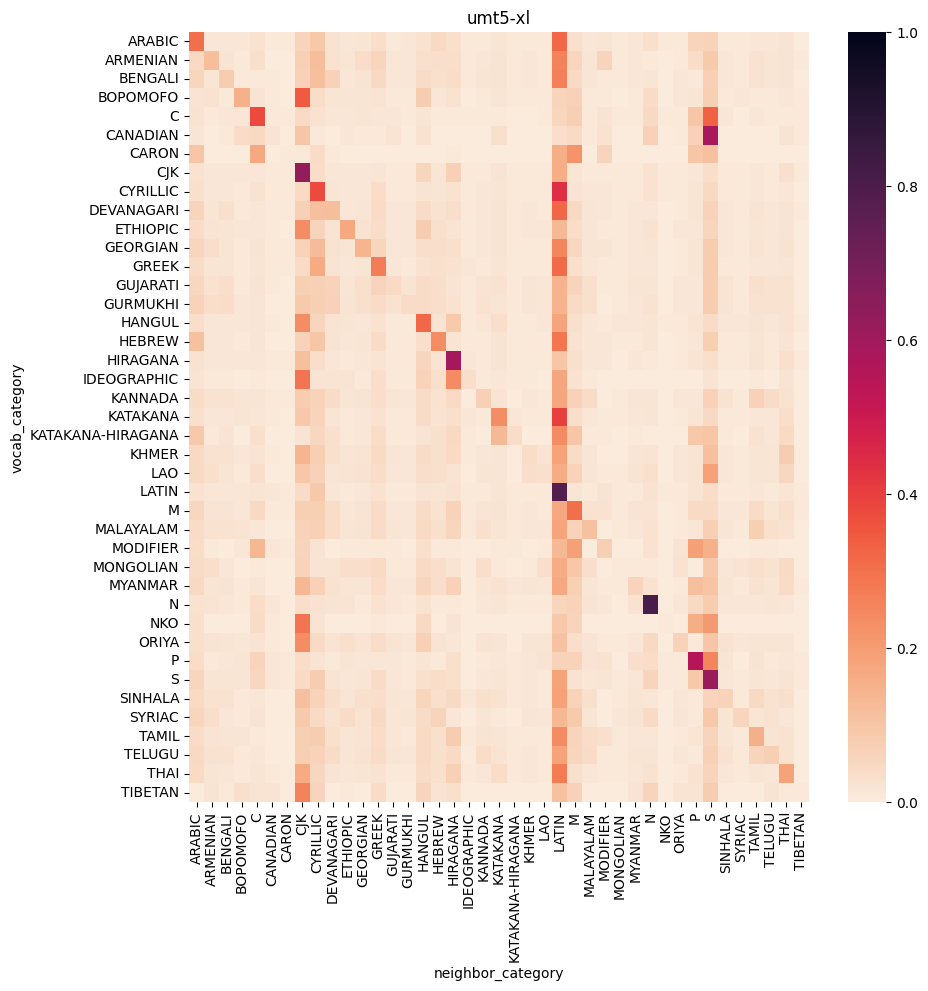

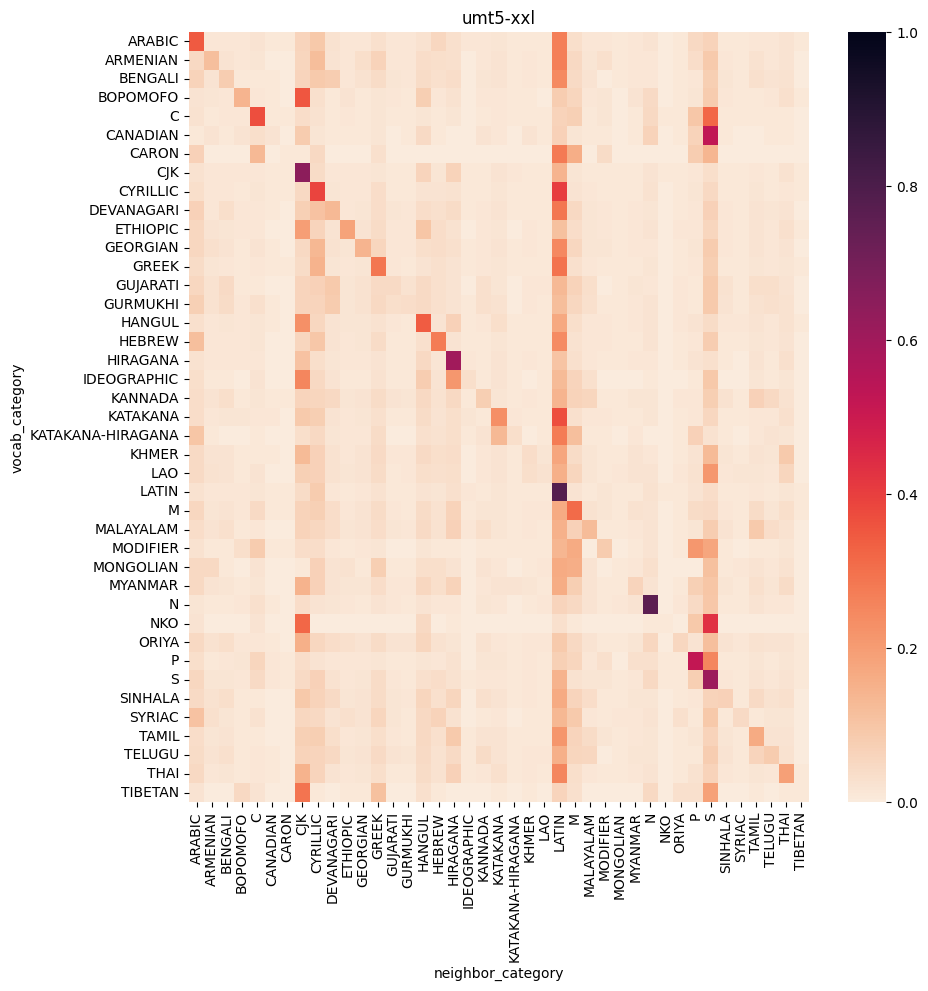

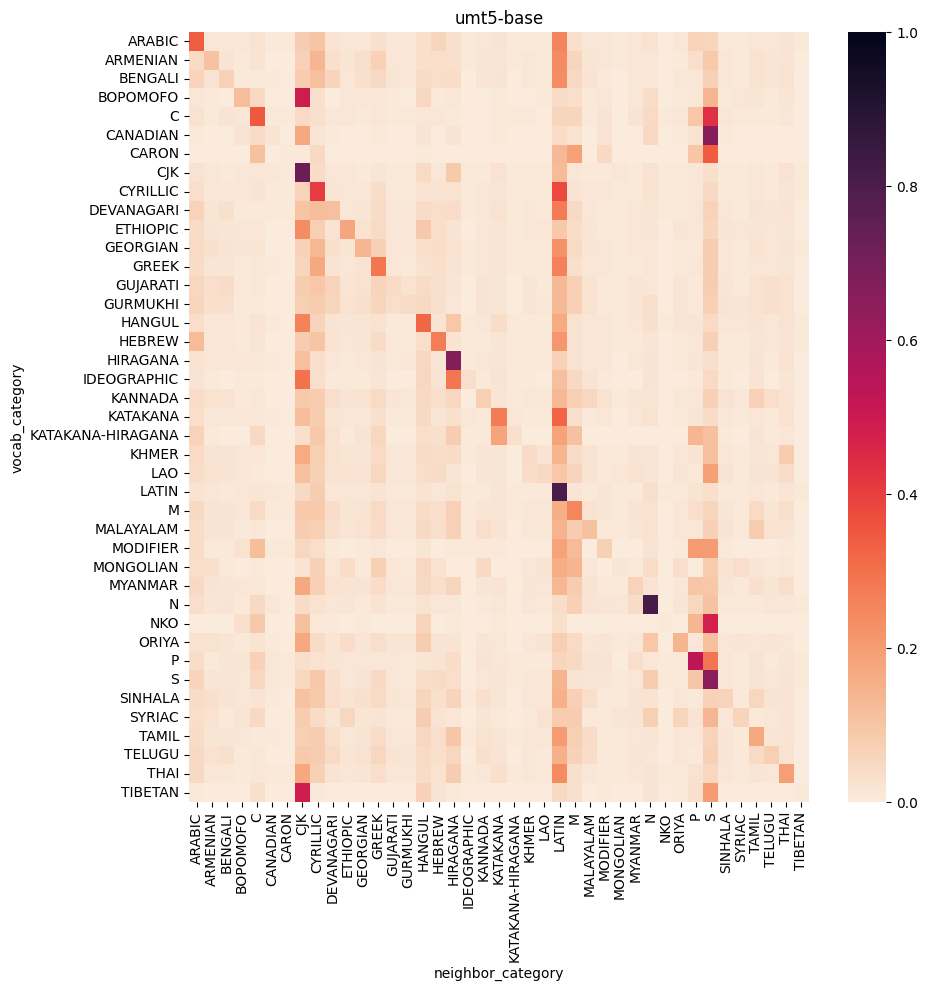

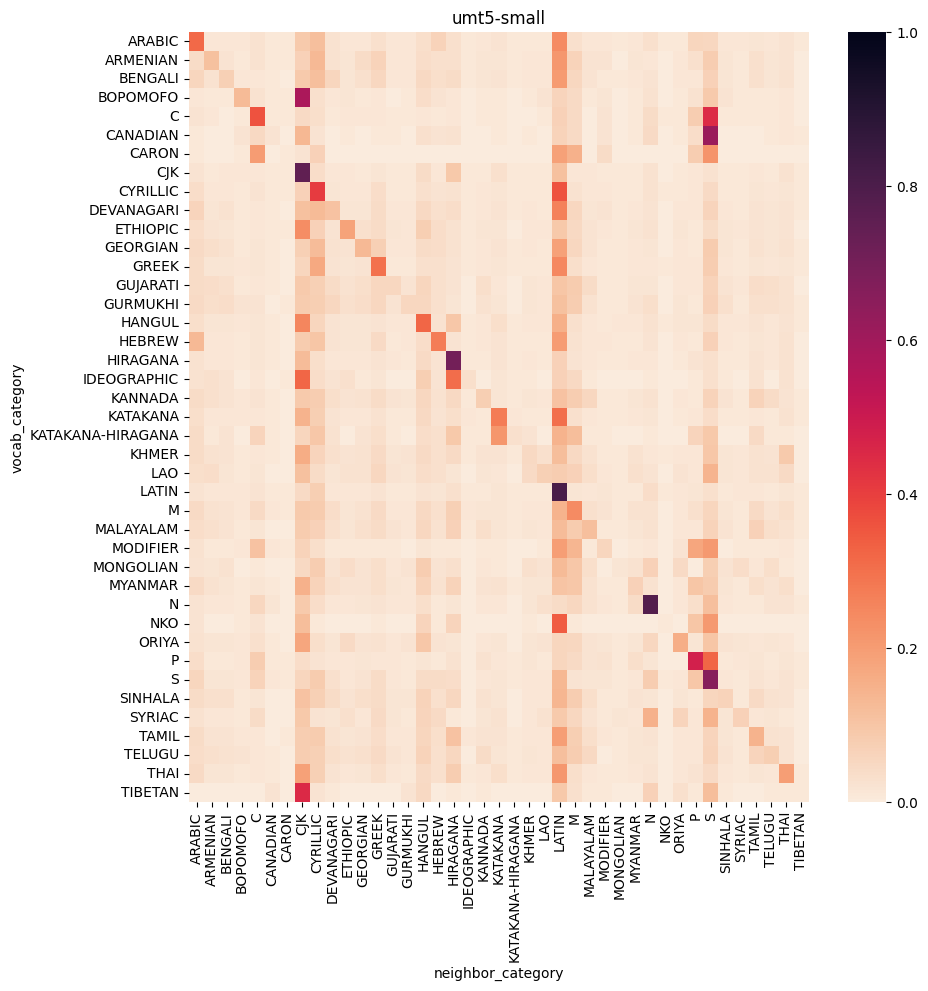

In [5]:
from pathlib import Path
model_dir = Path("./")
model_family = 'umt5'
model_names = [str(p) for p in model_dir.glob(f"{model_family}-*")]
for model_name in model_names:
    plot_category_heatmap(model_name)

In [ ]:
# class ModelVocabCharacter:
#     def __init__(self, model_family):
#         self.model_family = model_family
    
#         vocab_file = f'vocab/{model_family}_vocab.npy'
#         vocab = np.load(vocab_file, allow_pickle=True)
#         vocab_file = f'vocab/{model_family}_categories.npy'
#         vocab_categories = np.load(vocab_file, allow_pickle=True)
#         map_file = f'vocab/m_x_u_{model_family}_map.npy'
#         vocab_map = np.load(map_file, allow_pickle=True)
        
#         self.vocab = vocab
#         self.vocab_map = vocab_map
#         self.subset_vocab = vocab[vocab_map]
#         self.subset_vocab_categories = vocab_categories[vocab_map]

#     def translate_vocab_to_eng(self, dictionary):
#         cluster_ids = dictionary[dictionary['vocab'] == '食']['cluster_id'].values
#         dictionary[dictionary['cluster_id'] == cluster_ids[0]]
        
        
# # For each family
# # find semantic meaning by using dictionaries
